# Global Happiness Report Analysis
This notebook analyzes a synthetic dataset inspired by the World Happiness Report.

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("happiness_report_synthetic.csv")
df.head()


,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption,Dystopia_Residual,Region,Population,Unemployment_Rate,Education_Index,Environment_Index
0,Australia,2023,6.956406,46985.950279,0.252315,61.931866,0.200154,0.407164,0.847681,0.029821,Americas,147868343,13.350965,0.464724,0.411923
1,Germany,2022,6.692169,55329.704846,0.873043,68.129120,0.319589,0.409197,0.992590,0.258806,Europe,414861984,7.229769,0.609462,0.170296
2,Brazil,2010,6.252468,32349.834192,0.168858,82.578410,0.591808,0.544180,0.679393,0.503329,Asia,1370376887,10.897466,0.421858,0.022016
3,Australia,2022,2.216962,44487.058142,0.053635,66.089715,0.072229,0.543470,0.936688,0.859098,Africa,1479207000,9.751307,0.019126,0.211887
4,Canada,2022,3.818770,18138.469003,0.717465,64.309777,0.147453,0.497154,0.826949,0.974881,Oceania,861136600,7.623500,0.985519,0.536372


In [16]:
print(df.shape)

(1500, 15)


In [17]:
print(df.columns)

Index(['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita',
       'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity',
       'Corruption', 'Dystopia_Residual', 'Region', 'Population',
       'Unemployment_Rate', 'Education_Index', 'Environment_Index'],
      dtype='object')


In [18]:
print(df.dtypes)

Country                     object
Year                         int64
Happiness_Score            float64
GDP_per_Capita             float64
Social_Support             float64
Healthy_Life_Expectancy    float64
Freedom                    float64
Generosity                 float64
Corruption                 float64
Dystopia_Residual          float64
Region                      object
Population                   int64
Unemployment_Rate          float64
Education_Index            float64
Environment_Index          float64
dtype: object


In [19]:
print(df.tail())

        Country  Year  Happiness_Score  GDP_per_Capita  Social_Support  \
1495  Australia  2011         5.506693    60236.945364        0.108400   
1496     Canada  2017         5.229992    10086.396337        0.875933   
1497     Canada  2016         3.613121    49647.822538        0.783160   
1498     Canada  2010         4.210694    52196.463336        0.168118   
1499      Japan  2014         7.372077    47762.903643        0.512261   

      Healthy_Life_Expectancy   Freedom  Generosity  Corruption  \
1495                59.723437  0.961640    0.475198    0.670185   
1496                51.821199  0.511468    0.945118    0.175175   
1497                47.412299  0.733920    0.214458    0.473783   
1498                71.011451  0.411047    0.074159    0.648498   
1499                63.155700  0.355132    0.891454    0.028265   

      Dystopia_Residual   Region  Population  Unemployment_Rate  \
1495           1.290195  Oceania  1252302318           7.763229   
1496           1.1

## Basic Information about Dataset

In [20]:

# Dataset info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  1500 non-null   object 
 1   Year                     1500 non-null   int64  
 2   Happiness_Score          1500 non-null   float64
 3   GDP_per_Capita           1500 non-null   float64
 4   Social_Support           1500 non-null   float64
 5   Healthy_Life_Expectancy  1500 non-null   float64
 6   Freedom                  1500 non-null   float64
 7   Generosity               1500 non-null   float64
 8   Corruption               1500 non-null   float64
 9   Dystopia_Residual        1500 non-null   float64
 10  Region                   1500 non-null   object 
 11  Population               1500 non-null   int64  
 12  Unemployment_Rate        1500 non-null   float64
 13  Education_Index          1500 non-null   float64
 14  Environment_Index       

,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption,Dystopia_Residual,Population,Unemployment_Rate,Education_Index,Environment_Index
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03,1500.000000,1500.000000,1500.000000
mean,2016.979333,5.000750,34999.572800,0.496063,62.092235,0.486083,0.501208,0.505502,0.981548,7.429499e+08,10.312168,0.516584,0.502398
std,4.339062,1.739521,19674.904209,0.289973,12.887396,0.282931,0.285948,0.292094,0.578747,4.293311e+08,5.706018,0.285399,0.288484
min,2010.000000,2.000070,1002.119600,0.000227,40.010845,0.000243,0.000053,0.000158,0.002407,2.136045e+06,0.005049,0.001243,0.000612
25%,2013.000000,3.555952,17649.009492,0.244490,50.997881,0.248691,0.254807,0.253690,0.469597,3.586649e+08,5.607774,0.278327,0.260379
50%,2017.000000,5.009571,34995.908607,0.484596,61.836753,0.476873,0.501235,0.502401,0.967035,7.397027e+08,10.549670,0.517311,0.501061
75%,2021.000000,6.507364,51693.450429,0.749883,73.218412,0.720420,0.748602,0.763790,1.477393,1.107543e+09,15.061803,0.757391,0.749475
max,2024.000000,7.990085,69969.481524,0.999461,84.964328,0.996991,0.999505,0.999673,1.997690,1.499901e+09,19.982991,0.999871,0.999299


## Visualization: Correlations and Distributions

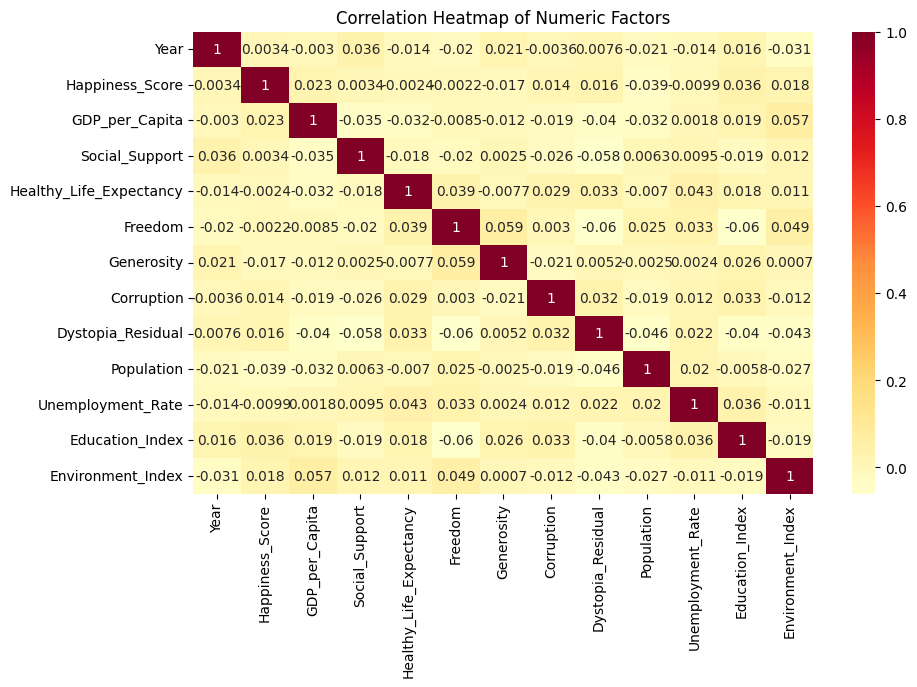

In [ ]:

# Correlation heatmap

plt.figure(figsize=(10,6))

# Select only numeric columns before correlation
corr = df.select_dtypes(include=["number"]).corr()

# Use yellow → orange → red colormap
sns.heatmap(corr, annot=True, cmap="YlOrRd")

plt.title("Correlation Heatmap of Numeric Factors")
plt.show()


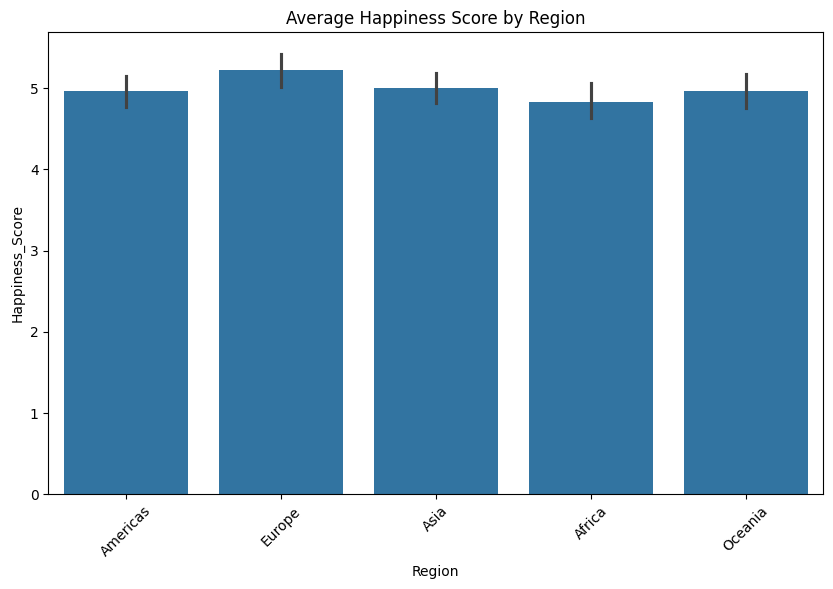

In [22]:

plt.figure(figsize=(10,6))
sns.barplot(x="Region", y="Happiness_Score", data=df, estimator="mean")
plt.title("Average Happiness Score by Region")
plt.xticks(rotation=45)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_14076\3832122668.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="Year", y="Happiness_Score", data=df, ci=None)


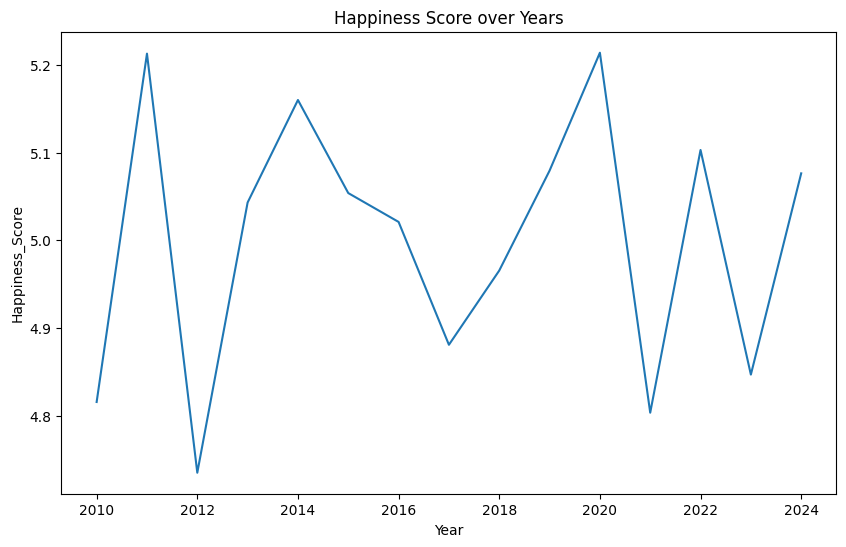

In [23]:

plt.figure(figsize=(10,6))
sns.lineplot(x="Year", y="Happiness_Score", data=df, ci=None)
plt.title("Happiness Score over Years")
plt.show()


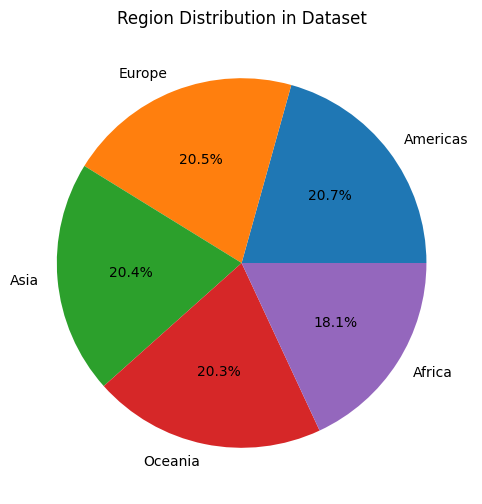

In [24]:

region_counts = df["Region"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
plt.title("Region Distribution in Dataset")
plt.show()


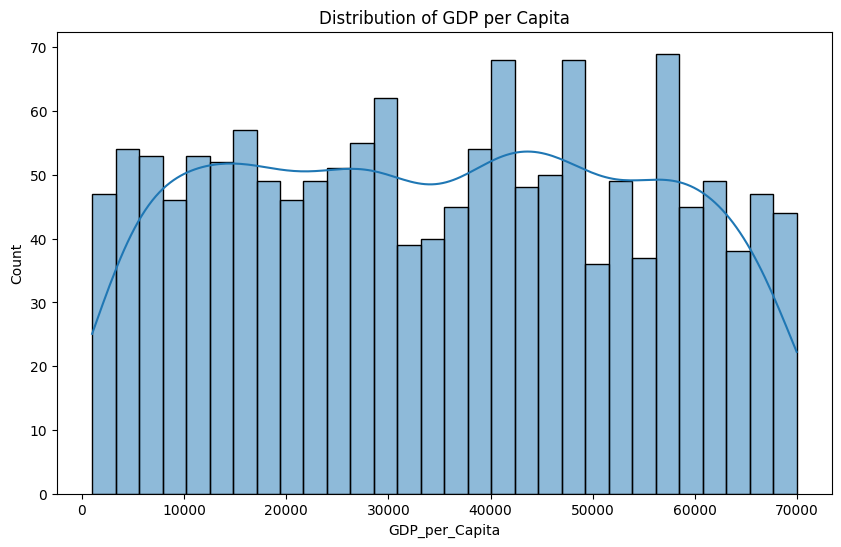

In [25]:

plt.figure(figsize=(10,6))
sns.histplot(df["GDP_per_Capita"], bins=30, kde=True)
plt.title("Distribution of GDP per Capita")
plt.show()


## Regression Plots: Relationship between Happiness Score and Key Factors

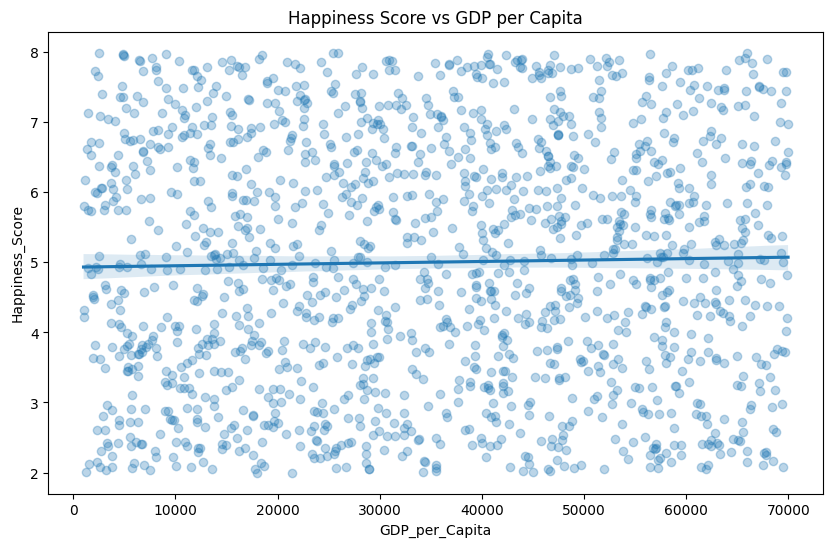

In [26]:

plt.figure(figsize=(10,6))
sns.regplot(x="GDP_per_Capita", y="Happiness_Score", data=df, scatter_kws={'alpha':0.3})
plt.title("Happiness Score vs GDP per Capita")
plt.show()


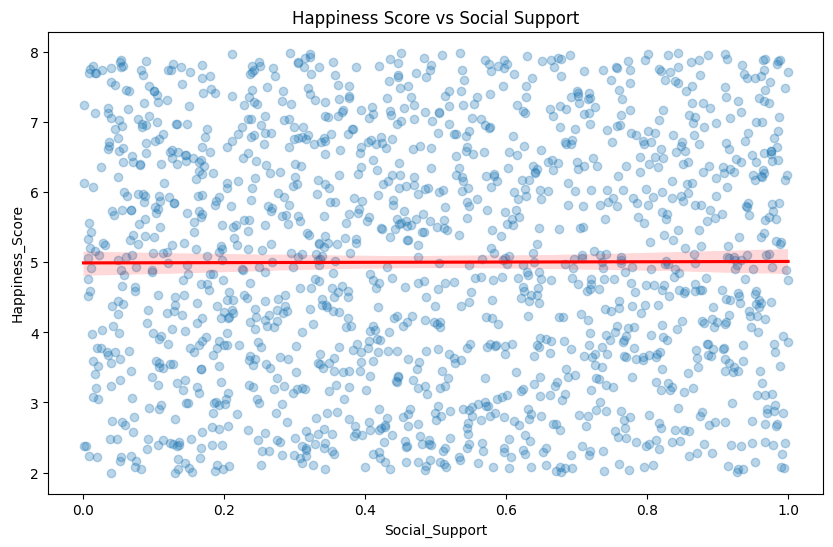

In [27]:

plt.figure(figsize=(10,6))
sns.regplot(x="Social_Support", y="Happiness_Score", data=df, scatter_kws={'alpha':0.3}, line_kws={"color":"red"})
plt.title("Happiness Score vs Social Support")
plt.show()


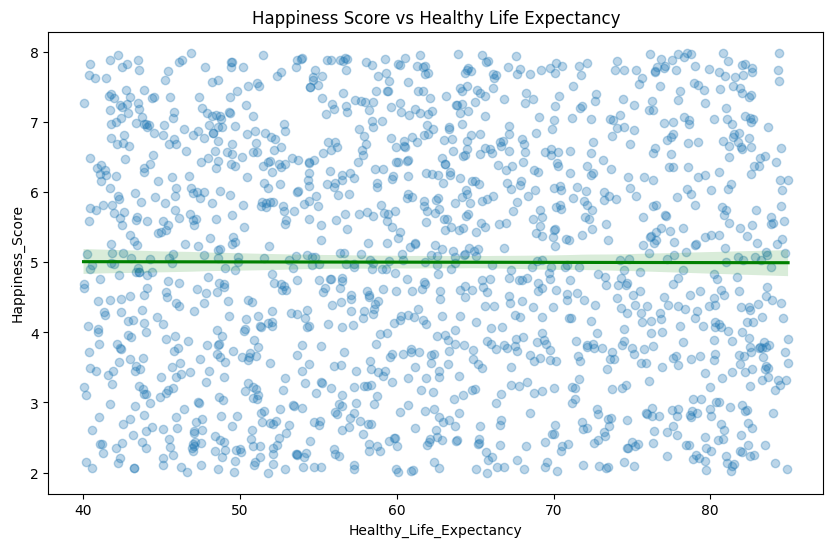

In [28]:

plt.figure(figsize=(10,6))
sns.regplot(x="Healthy_Life_Expectancy", y="Happiness_Score", data=df, scatter_kws={'alpha':0.3}, line_kws={"color":"green"})
plt.title("Happiness Score vs Healthy Life Expectancy")
plt.show()


## Pair Plot: Multi-variable Comparison

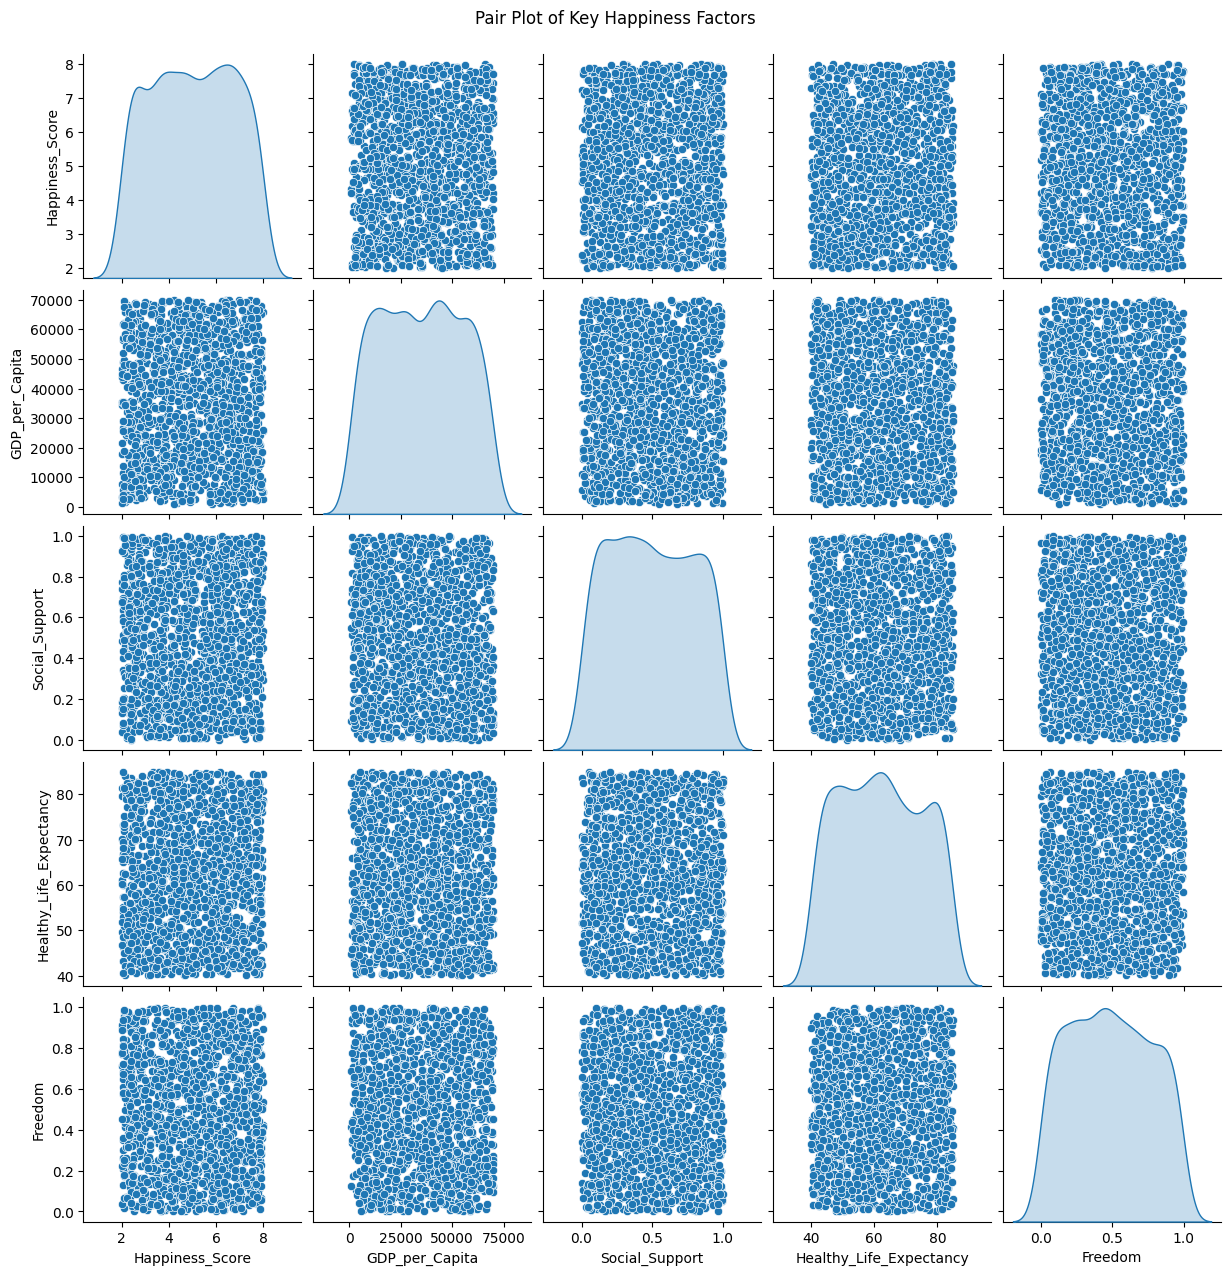

In [29]:

sns.pairplot(df[['Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom']], diag_kind='kde')
plt.suptitle("Pair Plot of Key Happiness Factors", y=1.02)
plt.show()
